# 1. Import Necessary Packages

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Data

In [33]:
df = pd.read_csv("../dataset/Churn_Modelling.csv")

In [34]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [35]:
df.shape

(10000, 14)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [37]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# 3. EDA (Exploratory Data Analysis)

In [38]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

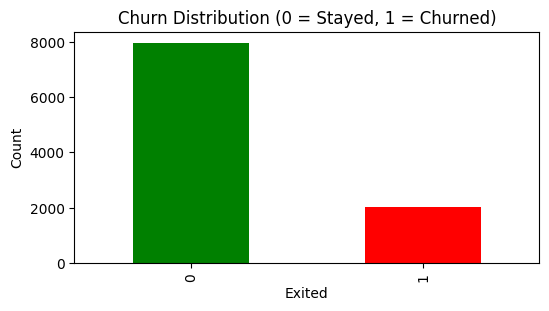

In [39]:
# Target distribution
plt.figure(figsize=(6,3))
df["Exited"].value_counts().plot(kind="bar",color=["green","red"])
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

In [40]:
# churn rate  bye Geography
pd.crosstab(df["Geography"], df["Exited"], normalize="index").mul(100).round(2)

Exited,0,1
Geography,,
France,83.85,16.15
Germany,67.56,32.44
Spain,83.33,16.67


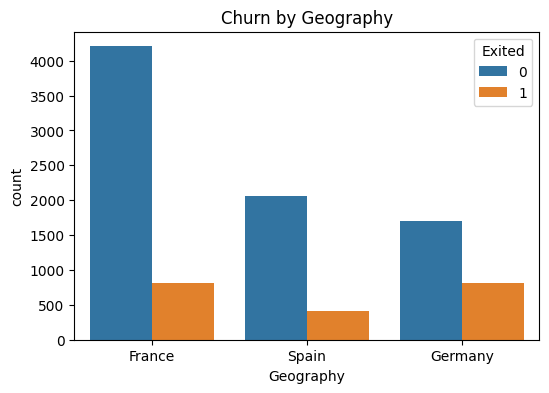

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Geography", hue="Exited")
plt.title("Churn by Geography")
plt.show()

In [42]:
# Churn rate by Gender
pd.crosstab(df["Gender"],df["Exited"], normalize="index").mul(100).round(2)

Exited,0,1
Gender,,
Female,74.93,25.07
Male,83.54,16.46


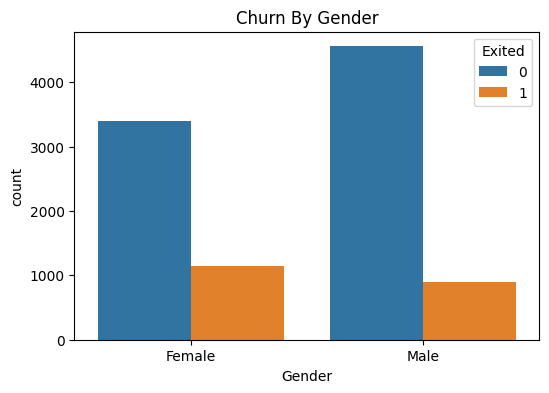

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Exited")
plt.title("Churn By Gender")
plt.show()

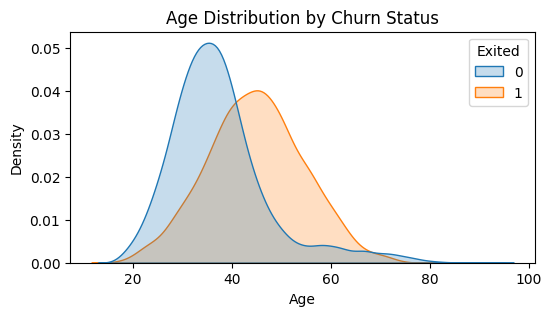

In [44]:
plt.figure(figsize=(6,3))
sns.kdeplot(data=df, x="Age", hue="Exited",fill=True, common_norm=False) # common_norm=False -> each class normalized independently
plt.title("Age Distribution by Churn Status")
plt.show()

# 4. Data Preprocessing

In [69]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [85]:
df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [86]:
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [87]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [88]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender (binary)
le_gender = LabelEncoder()
df_model["Gender"] = le_gender.fit_transform(df_model["Gender"])
print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

{'Female': np.int64(0), 'Male': np.int64(1)}


In [89]:
type(df_model)

pandas.DataFrame

In [90]:
# df_model = df.copy()

In [91]:
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [92]:
df["Geography"].unique()

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [93]:
# One-hot encode Geography (drop_first avoids redundant column)
df_model = pd.get_dummies(df_model, columns=["Geography"], drop_first=True)
df_model.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
